1. Importing libraries

In [18]:
import pandas as pd
import numpy as np

import pickle
import os

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.preprocessing import LabelEncoder

2. Dataset loading

In [19]:
df = pd.read_csv(
    "Sample - Superstore.csv",
    encoding="latin1"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


4. Data Modeling

In [20]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"]
)

5. Craeting time features

In [21]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"]
)


df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month

df["Quarter"] = df["Order Date"].dt.quarter


df["Day"] = df["Order Date"].dt.day



6. Aggregate Monthly Sales

In [22]:
monthly_sales = df.groupby(
    [
        "Year",
        "Month"
    ]
)["Sales"].sum().reset_index()


monthly_sales["Lag_1"] = (
    monthly_sales["Sales"]
    .shift(1)
)


monthly_sales["Lag_2"] = (
    monthly_sales["Sales"]
    .shift(2)
)


monthly_sales["Rolling_Mean"] = (
    monthly_sales["Sales"]
    .rolling(3)
    .mean()
)


monthly_sales.dropna(
    inplace=True
)

7. Creating previous cells features

In [23]:
monthly_sales["Previous_Sales"] = (
    monthly_sales["Sales"]
    .shift(1)
)


monthly_sales.dropna(
    inplace=True
)


monthly_sales.head()

,Year,Month,Sales,Lag_1,Lag_2,Rolling_Mean,Previous_Sales
3,2014,4,28295.3450,55691.0090,4519.8920,29502.082000,55691.0090
4,2014,5,23648.2870,28295.3450,55691.0090,35878.213667,28295.3450
5,2014,6,34595.1276,23648.2870,28295.3450,28846.253200,23648.2870
6,2014,7,33946.3930,34595.1276,23648.2870,30729.935867,34595.1276
7,2014,8,27909.4685,33946.3930,34595.1276,32150.329700,33946.3930


8. Featues and target

8.1. Features

In [24]:
X = monthly_sales[
[
"Year",
"Month",
"Lag_1",
"Lag_2",
"Rolling_Mean"
]
]

8.2. Target

In [25]:
y = monthly_sales["Sales"]

9. Train Test Split

In [26]:
split = int(
    len(X)*0.8
)


X_train = X[:split]

X_test = X[split:]


y_train = y[:split]

y_test = y[split:]

10. Training the model

In [27]:
from xgboost import XGBRegressor


model = XGBRegressor(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=5,

    random_state=42

)


model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

11. Prediction

In [28]:
predictions = model.predict(
    X_test
)

12. Evaluation

In [29]:
print(
    "MAE:",
    mean_absolute_error(
        y_test,
        predictions
    )
)

MAE: 10510.119679166668


In [30]:
print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )
)

RMSE: 13272.298734594391


In [31]:
print(
    "R2 Score:",
    r2_score(
        y_test,
        predictions
    )
)

R2 Score: 0.7172034621061396


**Actual vs Predicted Sales**

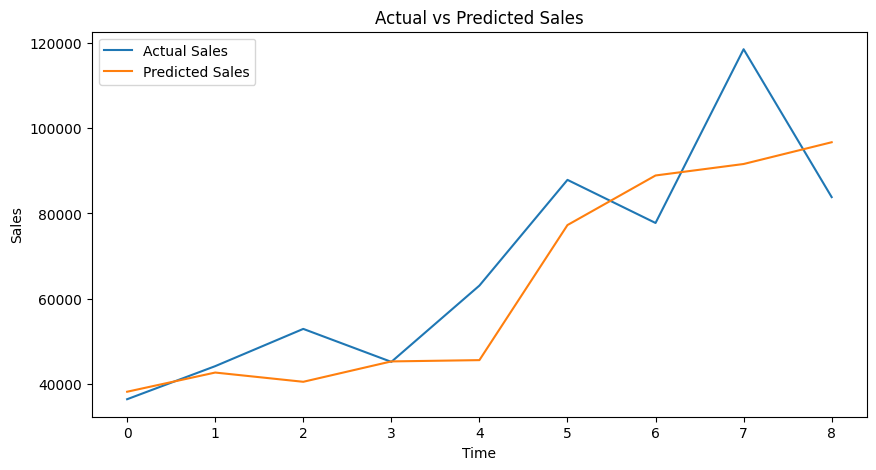

In [34]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))

plt.plot(
    y_test.values,
    label="Actual Sales"
)


plt.plot(
    predictions,
    label="Predicted Sales"
)


plt.title(
    "Actual vs Predicted Sales"
)

plt.xlabel(
    "Time"
)

plt.ylabel(
    "Sales"
)


plt.legend()

plt.show()

13. Saving the model

In [32]:
os.makedirs(
    "models",
    exist_ok=True
)

pickle.dump(

    model,

    open(
        "models/sales_forecast_model.pkl",
        "wb"
    )
)

14. Saving last sales values

In [33]:
pickle.dump(

    monthly_sales.iloc[-1],

    open(
        "models/latest_sales.pkl",
        "wb"
    )
)

Conclusion: R2 score ~71%